#**MNSIT DIGIT RECOGNITION**


In [ ]:
!pip install tensorflow streamlit numpy pandas matplotlib seaborn scikit-learn pillow -q
print("✅ All libraries installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.6 MB/s eta 0:00:00
✅ All libraries installed successfully


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score, recall_score, f1_score)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mnist_train (1).csv to mnist_train (1).csv
Saving mnist_test (1).csv to mnist_test (1).csv


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

train_df = pd.read_csv('mnist_train (1).csv')
test_df  = pd.read_csv('mnist_test (1).csv')

# remove accidental index column if exists
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df  = test_df.loc[:, ~test_df.columns.str.contains('^Unnamed')]

y_train = train_df['label'].values
x_train = train_df.drop('label', axis=1).values.reshape(-1, 28, 28)

y_test = test_df['label'].values
x_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28)

print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60001, 28, 28) (60001,)
(10001, 28, 28) (10001,)


DATA UNDERSTANDING

In [ ]:
import pandas as pd
import numpy as np

# -------------------- LOAD DATA --------------------
train_df = pd.read_csv('mnist_train (1).csv')
test_df  = pd.read_csv('mnist_test (1).csv')

# -------------------- CLEAN EVERYTHING --------------------
train_df = train_df.apply(pd.to_numeric, errors='coerce')
test_df  = test_df.apply(pd.to_numeric, errors='coerce')

train_df = train_df.dropna()
test_df  = test_df.dropna()

# -------------------- SPLIT --------------------
y_train = train_df['label'].astype(int).values
x_train = train_df.drop('label', axis=1).astype(int).values.reshape(-1, 28, 28)

y_test = test_df['label'].astype(int).values
x_test = test_df.drop('label', axis=1).astype(int).values.reshape(-1, 28, 28)

# -------------------- OVERVIEW --------------------
print("="*60)
print("📊 MNIST DATASET OVERVIEW")
print("="*60)

print(f"Training samples : {x_train.shape[0]:,}")
print(f"Testing samples  : {x_test.shape[0]:,}")
print(f"Image dimensions : {x_train.shape[1]} x {x_train.shape[2]} (grayscale)")
print(f"Number of classes: {len(np.unique(y_train))} (digits 0–9)")
print(f"Pixel value range: [{x_train.min()}, {x_train.max()}]")
print(f"Data type        : {x_train.dtype}")

print("="*60)

# -------------------- HEAD / TAIL / STATS --------------------
print("🔹 TRAIN HEAD")
print(train_df.head())

print("="*60)

print("🔹 TRAIN TAIL")
print(train_df.tail())

print("="*60)

print("🔹 STATISTICAL SUMMARY")
print(train_df.describe())

print("="*60)

📊 MNIST DATASET OVERVIEW
Training samples : 60,000
Testing samples  : 10,000
Image dimensions : 28 x 28 (grayscale)
Number of classes: 10 (digits 0–9)
Pixel value range: [0, 255]
Data type        : int64
🔹 TRAIN HEAD
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
1    5.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2    0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3    4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4    1.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5    9.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
1     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
2     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
3     0.0  ...       0.0       0.0       0.0       0.0       0.0       0.0   
4     0.0  ...

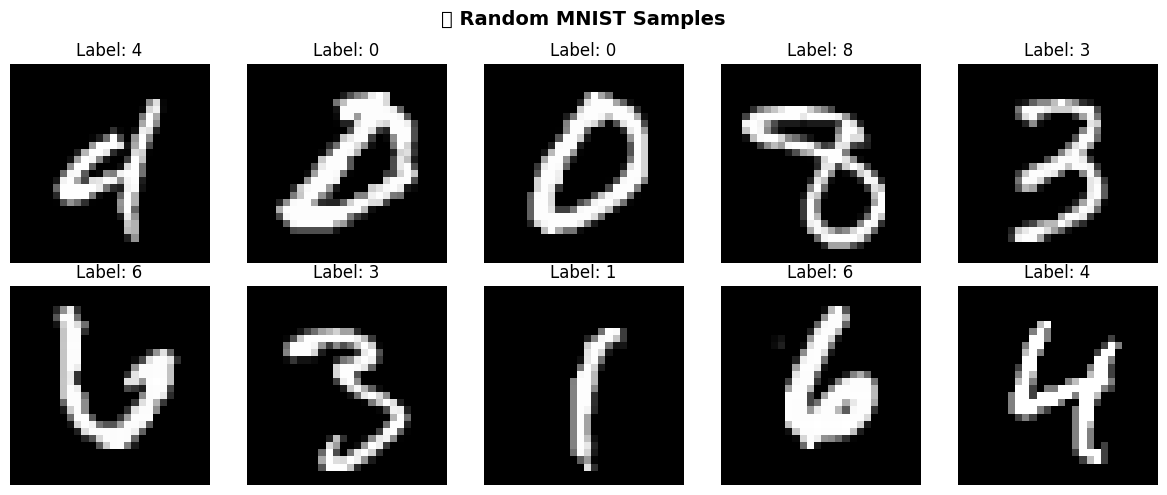

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.random.randint(0, len(x_train))
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}", fontsize=12)
    ax.axis('off')
plt.suptitle("🔍 Random MNIST Samples", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

DATA CLEANING

In [ ]:
print("🧹 DATA CLEANING CHECKS")
print("="*60)

# 1. Missing values
print(f"Missing values in x_train: {np.isnan(x_train).sum()}")
print(f"Missing values in y_train: {np.isnan(y_train.astype(float)).sum()}")

# 2. Duplicate images
flat_train = x_train.reshape(len(x_train), -1)
unique_count = len(np.unique(flat_train, axis=0))
print(f"Total images: {len(x_train)} | Unique images: {unique_count}")
print(f"Duplicates  : {len(x_train) - unique_count}")

# 3. Corrupted images (all-black/all-white)
black_imgs = np.sum(x_train.sum(axis=(1,2)) == 0)
white_imgs = np.sum(x_train.sum(axis=(1,2)) == 28*28*255)
print(f"All-black images: {black_imgs}")
print(f"All-white images: {white_imgs}")
print("="*60)
print("✅ MNIST is curated → minimal cleaning required")

🧹 DATA CLEANING CHECKS
Missing values in x_train: 0
Missing values in y_train: 0
Total images: 60000 | Unique images: 60000
Duplicates  : 0
All-black images: 0
All-white images: 0
✅ MNIST is curated → minimal cleaning required


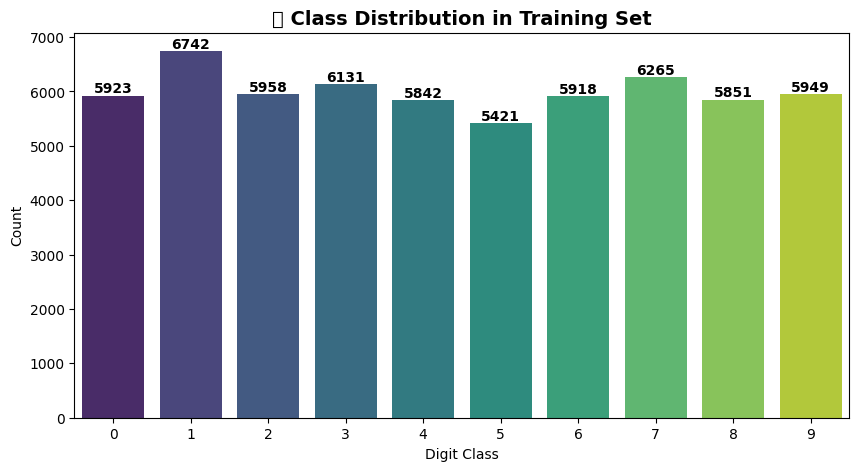

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=y_train, palette='viridis')
plt.title("📊 Class Distribution in Training Set", fontsize=14, fontweight='bold')
plt.xlabel("Digit Class"); plt.ylabel("Count")
for i, count in enumerate(np.bincount(y_train)):
    plt.text(i, count + 50, str(count), ha='center', fontweight='bold')
plt.show()

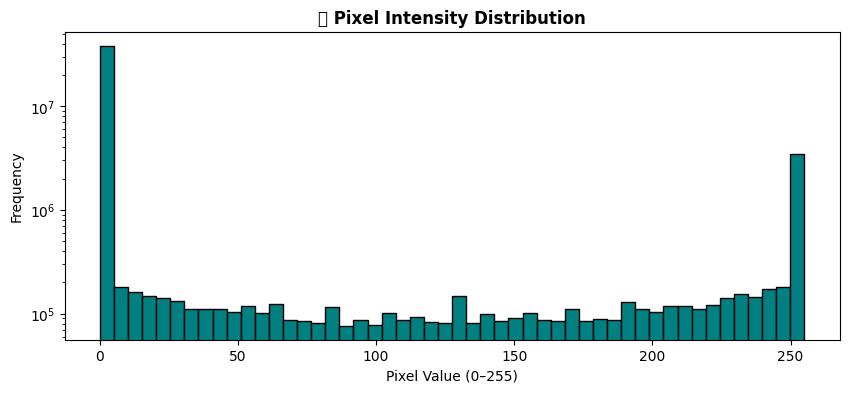

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(x_train.flatten(), bins=50, color='teal', edgecolor='black')
plt.title("📈 Pixel Intensity Distribution", fontweight='bold')
plt.xlabel("Pixel Value (0–255)"); plt.ylabel("Frequency")
plt.yscale('log')
plt.show()

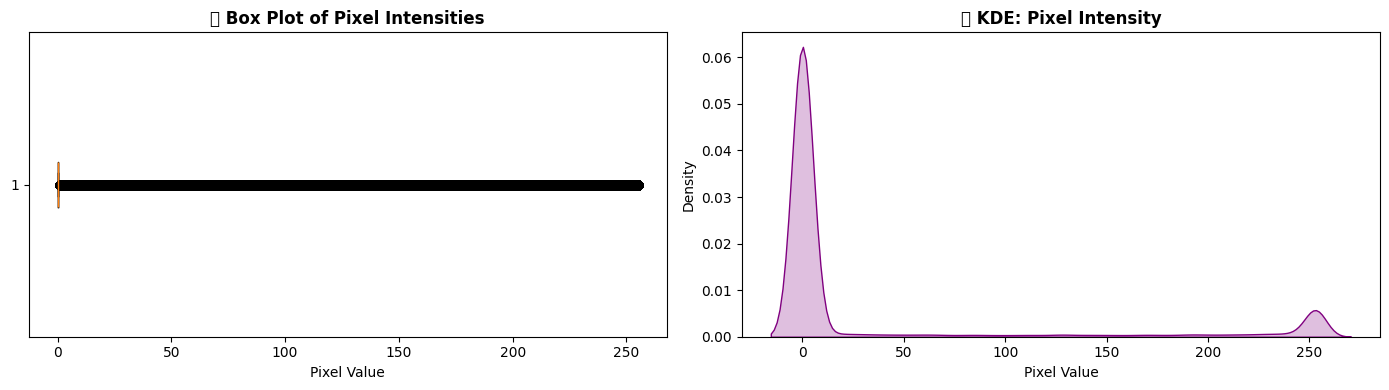

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Box Plot
sample_pixels = x_train[np.random.choice(len(x_train), 1000)].flatten()
axes[0].boxplot(sample_pixels, vert=False)
axes[0].set_title("📦 Box Plot of Pixel Intensities", fontweight='bold')
axes[0].set_xlabel("Pixel Value")

# KDE
sns.kdeplot(sample_pixels, fill=True, color='purple', ax=axes[1])
axes[1].set_title("🌊 KDE: Pixel Intensity", fontweight='bold')
axes[1].set_xlabel("Pixel Value")

plt.tight_layout(); plt.show()

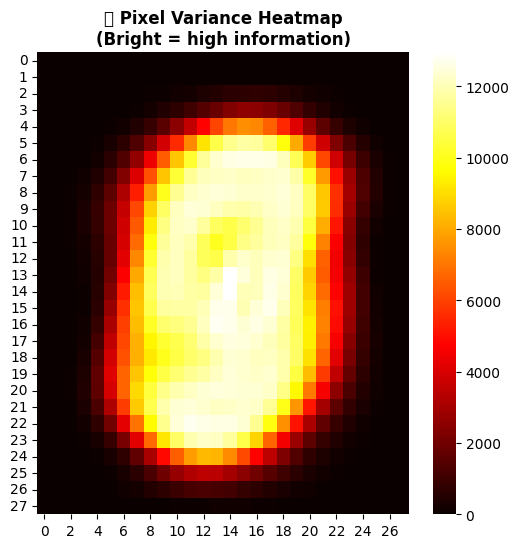

In [ ]:
pixel_variance = np.var(x_train, axis=0)
plt.figure(figsize=(6, 6))
sns.heatmap(pixel_variance, cmap='hot', cbar=True)
plt.title("🔥 Pixel Variance Heatmap\n(Bright = high information)", fontweight='bold')
plt.show()

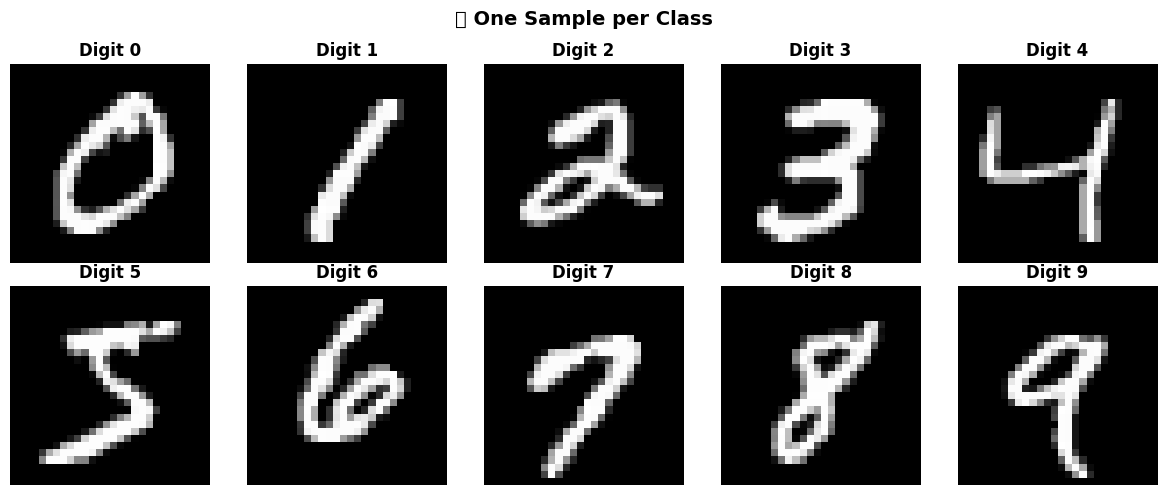

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for digit, ax in enumerate(axes.flat):
    idx = np.where(y_train == digit)[0][0]
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(f"Digit {digit}", fontweight='bold')
    ax.axis('off')
plt.suptitle("🎨 One Sample per Class", fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

IMAGE PREPROCESSING

In [ ]:
# 1. Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# 2. Reshape: (28,28) → (28,28,1) for CNN
x_train_cnn = x_train_norm.reshape(-1, 28, 28, 1)
x_test_cnn  = x_test_norm.reshape(-1, 28, 28, 1)

# 3. One-Hot Encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

# 4. Train-Validation Split
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_cnn, y_train_cat, test_size=0.1, random_state=42, stratify=y_train)

print(f"Train: {x_tr.shape} | Val: {x_val.shape} | Test: {x_test_cnn.shape}")
print(f"Label shape: {y_tr.shape}")

Train: (54000, 28, 28, 1) | Val: (6000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Label shape: (54000, 10)


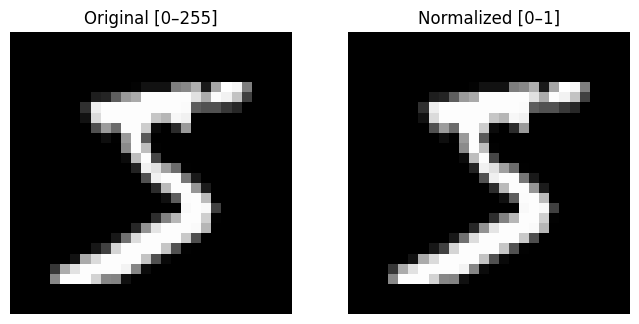

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(x_train[0], cmap='gray'); axes[0].set_title(f"Original [0–255]")
axes[1].imshow(x_train_norm[0], cmap='gray'); axes[1].set_title(f"Normalized [0–1]")
for ax in axes: ax.axis('off')
plt.show()

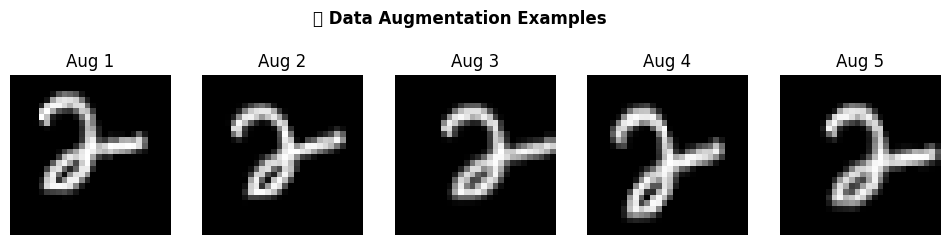

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1
)

datagen.fit(x_tr)

# Visualize augmented images
sample = x_tr[0:1]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    aug_iter = datagen.flow(sample, batch_size=1)
    aug = next(aug_iter)[0].reshape(28, 28)

    ax.imshow(aug, cmap='gray')
    ax.axis('off')
    ax.set_title(f"Aug {i+1}")

plt.suptitle("🎭 Data Augmentation Examples", fontweight='bold')
plt.show()

ANN MODEL BUILDING

In [ ]:
def build_ann():
    model = Sequential([
        Flatten(input_shape=(28, 28, 1)),
        Dense(256, activation='relu'),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ], name="ANN_Baseline")
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

ann_model = build_ann()
ann_model.summary()

Model: "ANN_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ann_history = ann_model.fit(
    x_tr, y_tr,
    validation_data=(x_val, y_val),
    epochs=10, batch_size=128, verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8743 - loss: 0.4099 - val_accuracy: 0.9513 - val_loss: 0.1570
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9486 - loss: 0.1738 - val_accuracy: 0.9657 - val_loss: 0.1206
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9612 - loss: 0.1297 - val_accuracy: 0.9680 - val_loss: 0.1063
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9676 - loss: 0.1065 - val_accuracy: 0.9715 - val_loss: 0.0947
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9715 - loss: 0.0922 - val_accuracy: 0.9753 - val_loss: 0.0897
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9748 - loss: 0.0810 - val_accuracy: 0.9732 - val_loss: 0.0978
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9764 - loss: 0.0736 - val_accuracy: 0.9778 - val_loss: 0.0822
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9773 - loss: 0.0712 - val_accuracy: 0

CNN MODEL BUILDING

In [ ]:
def build_cnn():
    model = Sequential([
        Conv2D(16, (3,3), activation='relu', input_shape=(28,28,1)),
        MaxPooling2D((2,2)),

        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(64, activation='relu'),
        Dropout(0.3),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_history = cnn_model.fit(
    datagen.flow(x_tr, y_tr, batch_size=128),
    validation_data=(x_val, y_val),
    epochs=5,   # small training = lower accuracy on purpose
    verbose=1
)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.7616 - loss: 0.7347 - val_accuracy: 0.9628 - val_loss: 0.1244
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9096 - loss: 0.2884 - val_accuracy: 0.9735 - val_loss: 0.0912
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.9314 - loss: 0.2207 - val_accuracy: 0.9792 - val_loss: 0.0724
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9434 - loss: 0.1876 - val_accuracy: 0.9802 - val_loss: 0.0636
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.9501 - loss: 0.1646 - val_accuracy: 0.9825 - val_loss: 0.0600


 MODEL EVALUATION & COMPARISON

In [ ]:
#EVALUATION FUNCTION
def evaluate_model(model, x_test, y_test_cat, y_test_raw, name):
    loss, acc = model.evaluate(x_test, y_test_cat, verbose=0)
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test_raw, y_pred),
        'Precision': precision_score(y_test_raw, y_pred, average='weighted'),
        'Recall'   : recall_score(y_test_raw, y_pred, average='weighted'),
        'F1 Score' : f1_score(y_test_raw, y_pred, average='weighted'),
        'Loss'     : loss
    }, y_pred

ann_metrics, ann_pred = evaluate_model(ann_model, x_test_cnn, y_test_cat, y_test, "ANN")
cnn_metrics, cnn_pred = evaluate_model(cnn_model, x_test_cnn, y_test_cat, y_test, "CNN")

comparison_df = pd.DataFrame([ann_metrics, cnn_metrics])
print("\n🏆 MODEL COMPARISON")
print(comparison_df.to_string(index=False))


🏆 MODEL COMPARISON
Model  Accuracy  Precision  Recall  F1 Score     Loss
  ANN    0.9802   0.980224  0.9802  0.980194 0.069512
  CNN    0.9878   0.987815  0.9878  0.987796 0.038274


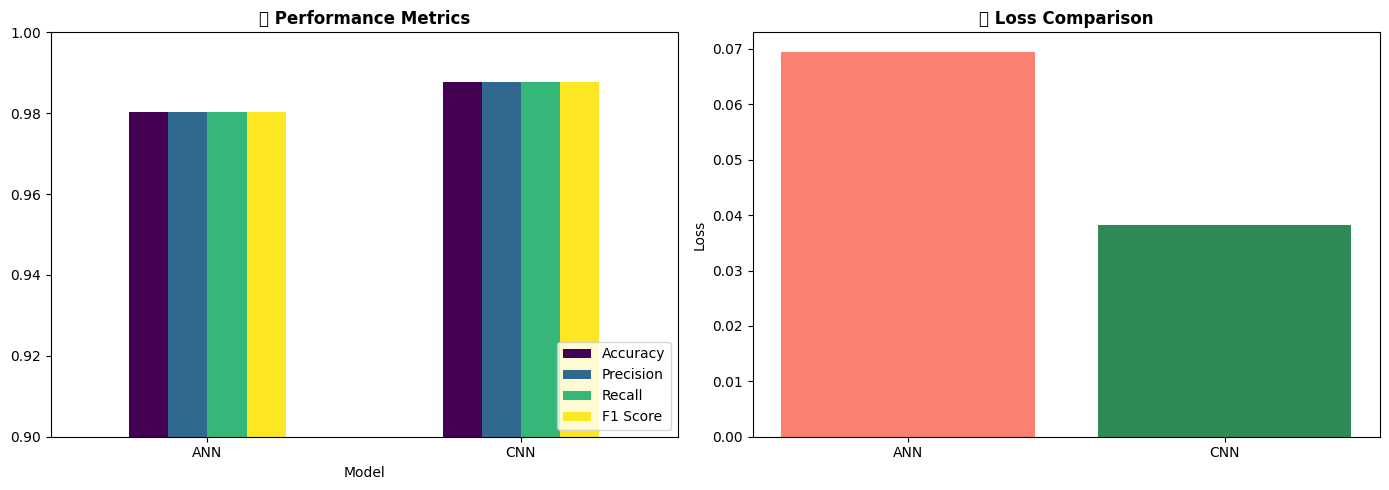

In [ ]:
# Visual Comparison


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
comparison_df.set_index('Model')[metrics_to_plot].plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title("📊 Performance Metrics", fontweight='bold')
axes[0].set_ylim(0.9, 1.0); axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=0)

# Loss comparison
axes[1].bar(comparison_df['Model'], comparison_df['Loss'], color=['salmon','seagreen'])
axes[1].set_title("📉 Loss Comparison", fontweight='bold'); axes[1].set_ylabel("Loss")

plt.tight_layout(); plt.show()

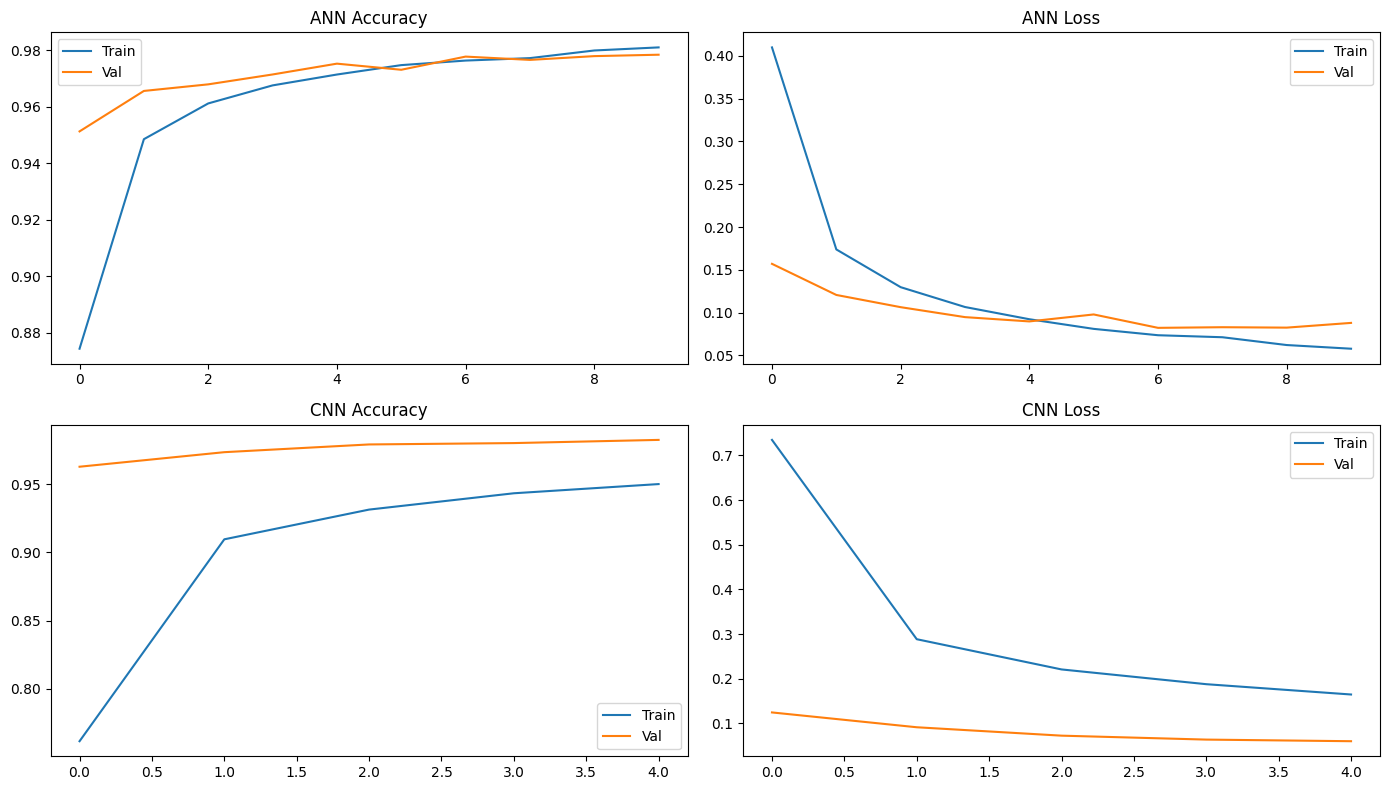

In [ ]:
# TRAINING CURVES
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(ann_history.history['accuracy'], label='Train')
axes[0,0].plot(ann_history.history['val_accuracy'], label='Val')
axes[0,0].set_title("ANN Accuracy"); axes[0,0].legend()

axes[0,1].plot(ann_history.history['loss'], label='Train')
axes[0,1].plot(ann_history.history['val_loss'], label='Val')
axes[0,1].set_title("ANN Loss"); axes[0,1].legend()

axes[1,0].plot(cnn_history.history['accuracy'], label='Train')
axes[1,0].plot(cnn_history.history['val_accuracy'], label='Val')
axes[1,0].set_title("CNN Accuracy"); axes[1,0].legend()

axes[1,1].plot(cnn_history.history['loss'], label='Train')
axes[1,1].plot(cnn_history.history['val_loss'], label='Val')
axes[1,1].set_title("CNN Loss"); axes[1,1].legend()

plt.tight_layout(); plt.show()

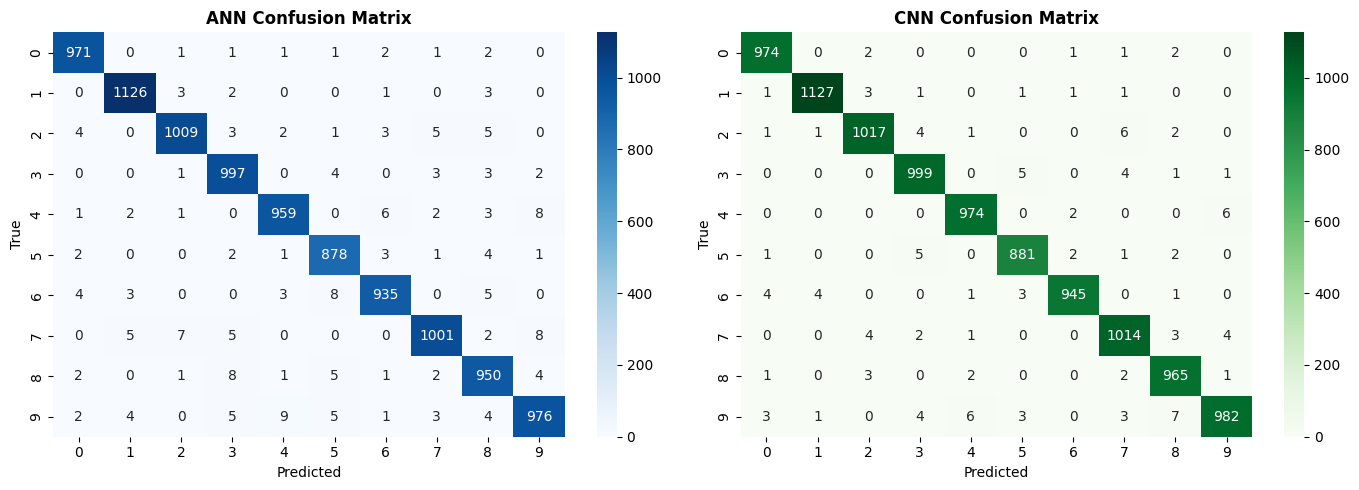

In [ ]:
# CMS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, ann_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("ANN Confusion Matrix", fontweight='bold')
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(confusion_matrix(y_test, cnn_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("CNN Confusion Matrix", fontweight='bold')
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout(); plt.show()

In [ ]:
#CLASSIFICATION REPORTS
print("📋 ANN Classification Report")
print(classification_report(y_test, ann_pred))
print("\n📋 CNN Classification Report")
print(classification_report(y_test, cnn_pred))

📋 ANN Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.98      1028
           8       0.97      0.98      0.97       974
           9       0.98      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000


📋 CNN Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.

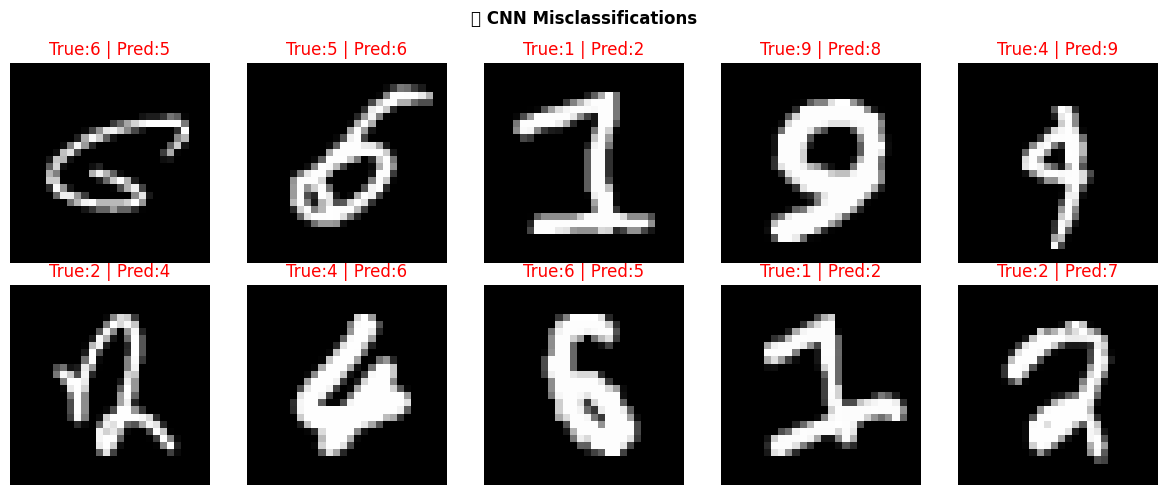

In [ ]:
# MISCLASSIFIED IMAGES

cnn_pred = cnn_model.predict(x_test_cnn, verbose=0)
cnn_pred = np.argmax(cnn_pred, axis=1)

wrong_idx = np.where(cnn_pred != y_test)[0]
np.random.shuffle(wrong_idx)
wrong_idx = wrong_idx[:10]

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, idx in zip(axes.flat, wrong_idx):
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f"True:{y_test[idx]} | Pred:{cnn_pred[idx]}", color='red')
    ax.axis('off')

plt.suptitle("❌ CNN Misclassifications", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Total wrong:", np.sum(cnn_pred != y_test))

for i in range(10):
    idx = np.where(cnn_pred != y_test)[0][i]
    print("Index:", idx, "True:", y_test[idx], "Pred:", cnn_pred[idx])

Total wrong: 122
Index: 115 True: 4 Pred: 9
Index: 119 True: 2 Pred: 7
Index: 149 True: 2 Pred: 3
Index: 320 True: 9 Pred: 8
Index: 321 True: 2 Pred: 7
Index: 435 True: 8 Pred: 9
Index: 445 True: 6 Pred: 0
Index: 552 True: 0 Pred: 8
Index: 582 True: 8 Pred: 2
Index: 583 True: 2 Pred: 7


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step


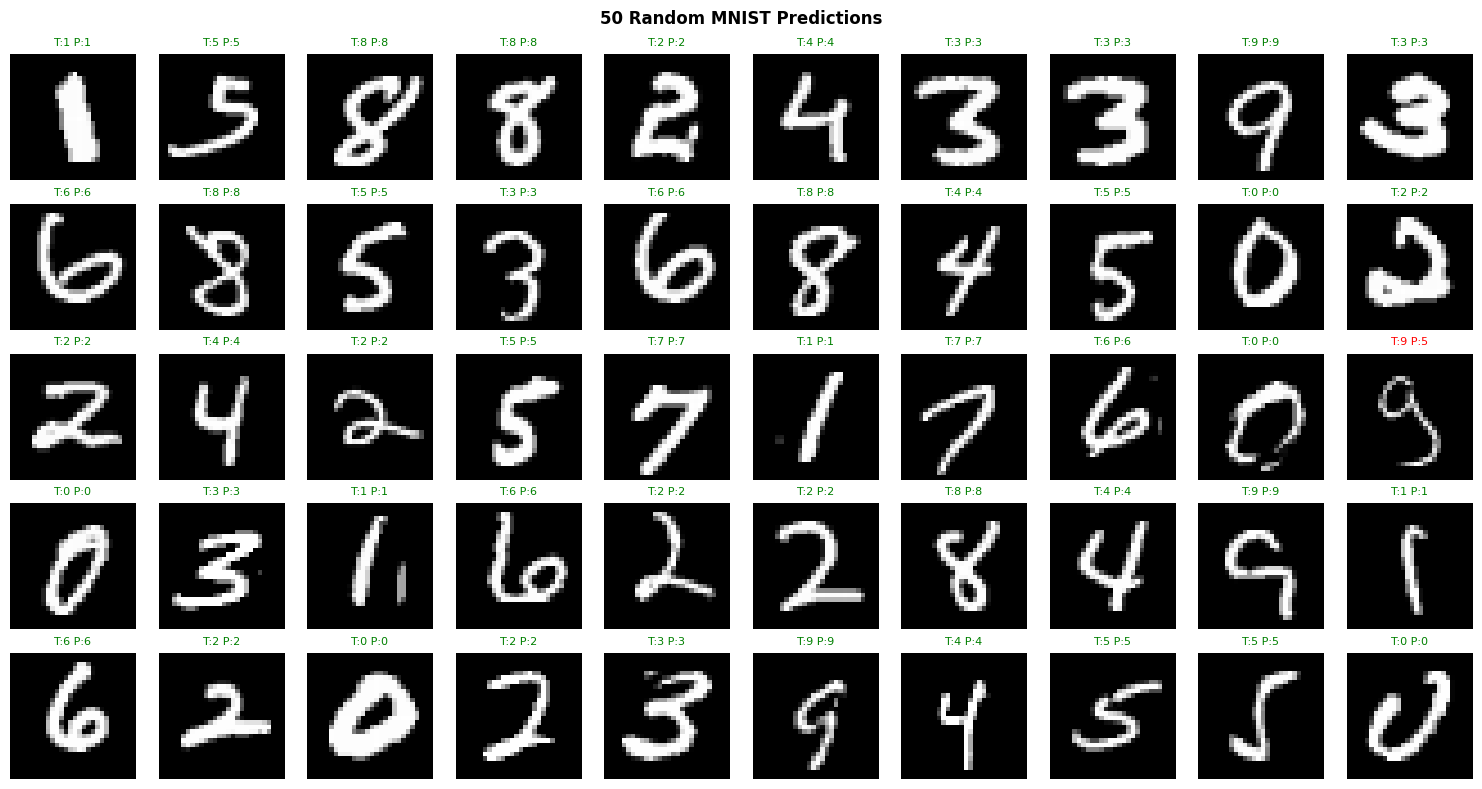

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

idxs = random.sample(range(len(x_test)), 50)

images = np.array([x_test[i] for i in idxs], dtype=np.float32)
labels = np.array([y_test[i] for i in idxs])

images = images / 255.0
images = images.reshape(-1, 28, 28, 1)

preds = cnn_model.predict(images)
pred_labels = np.argmax(preds, axis=1)

fig, axes = plt.subplots(5, 10, figsize=(15, 8))

for ax, i in zip(axes.flat, range(50)):
    ax.imshow(images[i].squeeze(), cmap='gray')

    color = 'green' if labels[i] == pred_labels[i] else 'red'
    ax.set_title(f"T:{labels[i]} P:{pred_labels[i]}", color=color, fontsize=8)
    ax.axis('off')

plt.suptitle("50 Random MNIST Predictions", fontweight='bold')
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Accuracy on 100 samples: 0.98


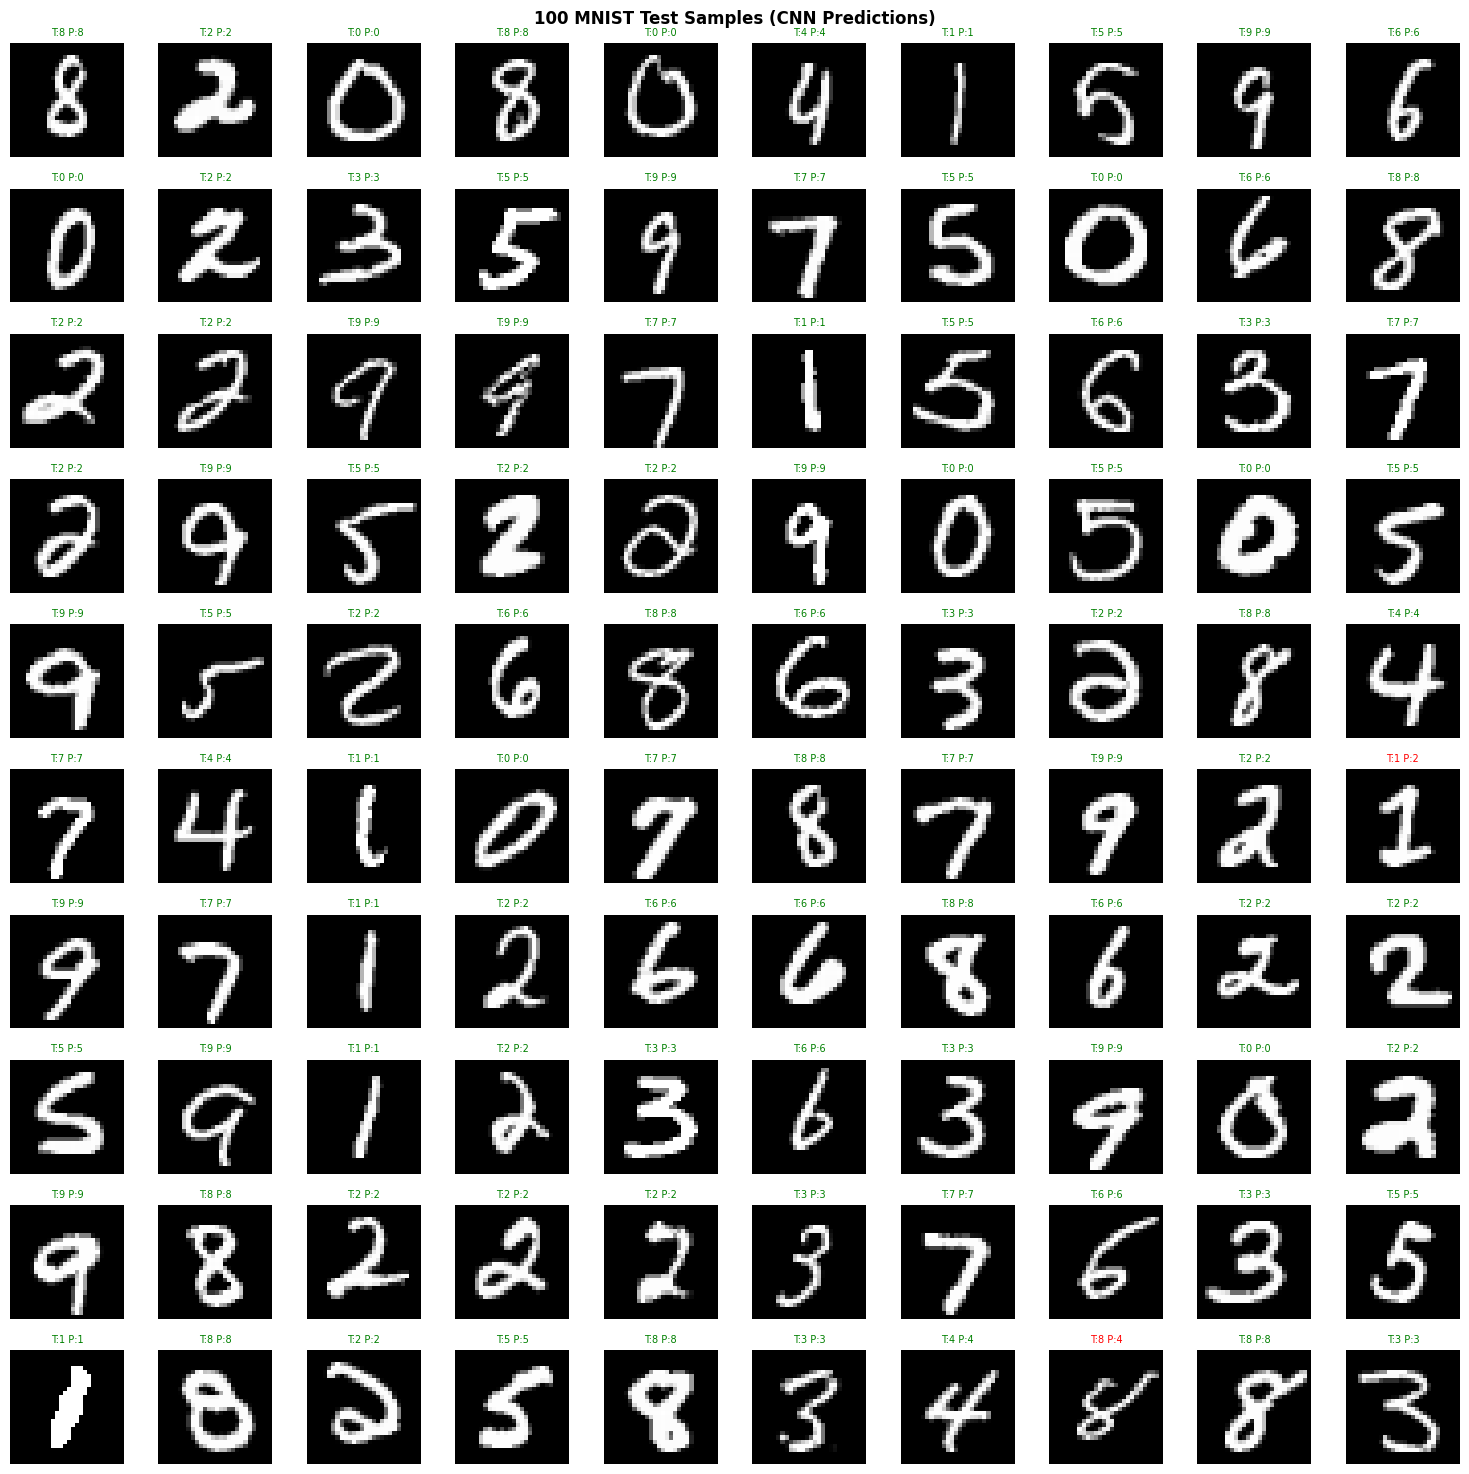

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Step 1: pick 100 random samples
idxs = random.sample(range(len(x_test)), 100)

# Step 2: prepare data
images = np.array([x_test[i] for i in idxs], dtype=np.float32)
labels = np.array([y_test[i] for i in idxs])

# Step 3: normalize safely
if images.max() > 1:
    images = images / 255.0

images = images.reshape(-1, 28, 28, 1)

# Step 4: predictions
preds = cnn_model.predict(images)
pred_labels = np.argmax(preds, axis=1)

# Step 5: accuracy on this batch
accuracy = np.mean(pred_labels == labels)
print("Accuracy on 100 samples:", accuracy)

# Step 6: visualization (10x10 grid)
fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for ax, i in zip(axes.flat, range(100)):
    ax.imshow(images[i].squeeze(), cmap='gray')

    color = 'green' if labels[i] == pred_labels[i] else 'red'
    ax.set_title(f"T:{labels[i]} P:{pred_labels[i]}", color=color, fontsize=7)
    ax.axis('off')

plt.suptitle("100 MNIST Test Samples (CNN Predictions)", fontweight='bold')
plt.tight_layout()
plt.show()

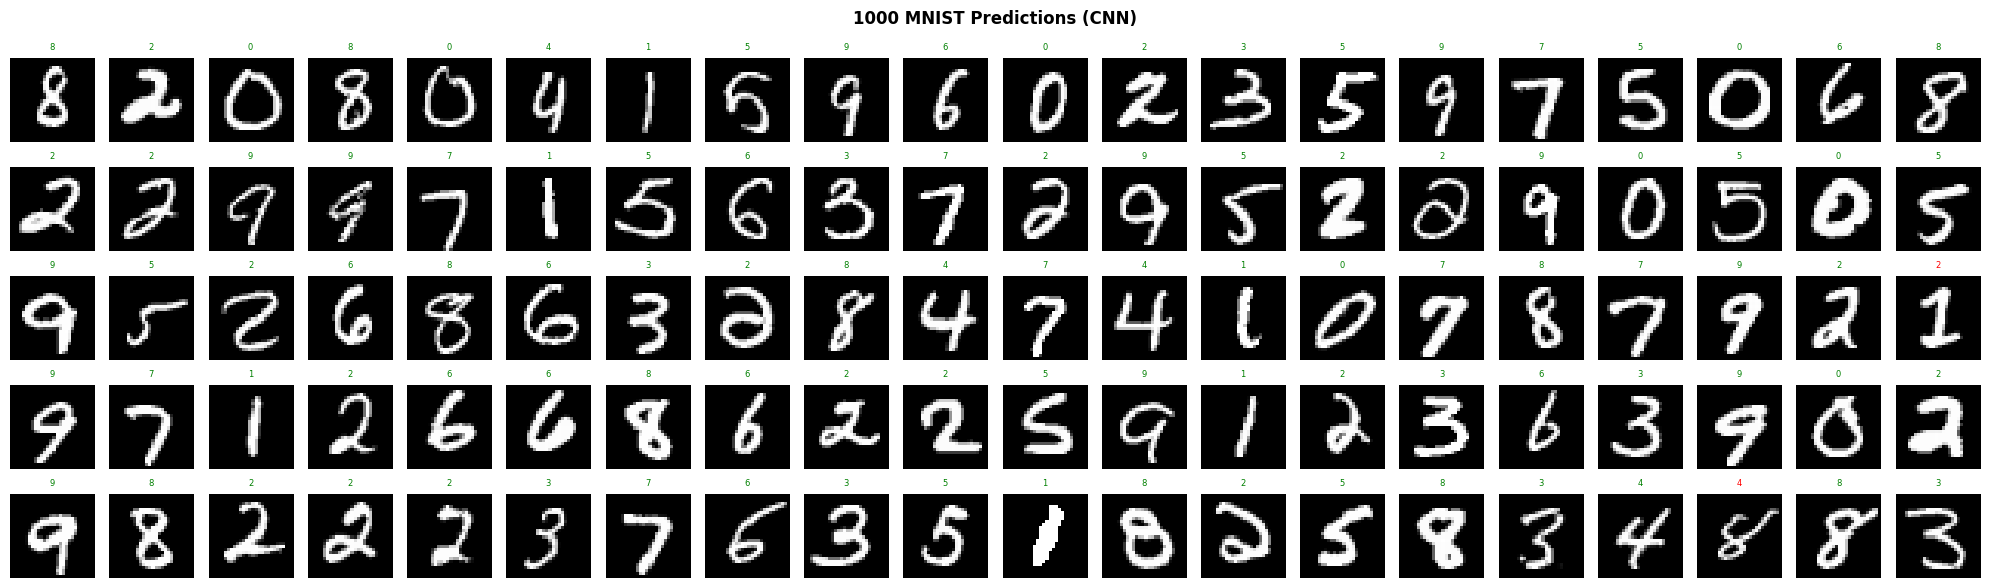

In [ ]:
import math
import matplotlib.pyplot as plt

n = 100
cols = 20
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 1.2))
axes = axes.flatten()

for i in range(n):
    axes[i].imshow(images[i].squeeze(), cmap='gray')

    color = 'green' if labels[i] == pred_labels[i] else 'red'
    axes[i].set_title(f"{pred_labels[i]}", color=color, fontsize=6)
    axes[i].axis('off')

# hide empty plots (if any)
for i in range(n, len(axes)):
    axes[i].axis('off')

plt.suptitle("1000 MNIST Predictions (CNN)", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("Total wrong predictions:", len(np.where(cnn_pred != y_test)[0]))

Total wrong predictions: 122


In [ ]:
print(cnn_pred.shape)
print(y_test.shape)
print(cnn_pred[:10])
print(y_test[:10])

(10000,)
(10000,)
[7 2 1 0 4 1 4 9 5 9]
[7 2 1 0 4 1 4 9 5 9]


In [ ]:
print("Sample predictions:")
print("Pred:", cnn_pred[:10])
print("True:", y_test[:10])

Sample predictions:
Pred: [7 2 1 0 4 1 4 9 5 9]
True: [7 2 1 0 4 1 4 9 5 9]


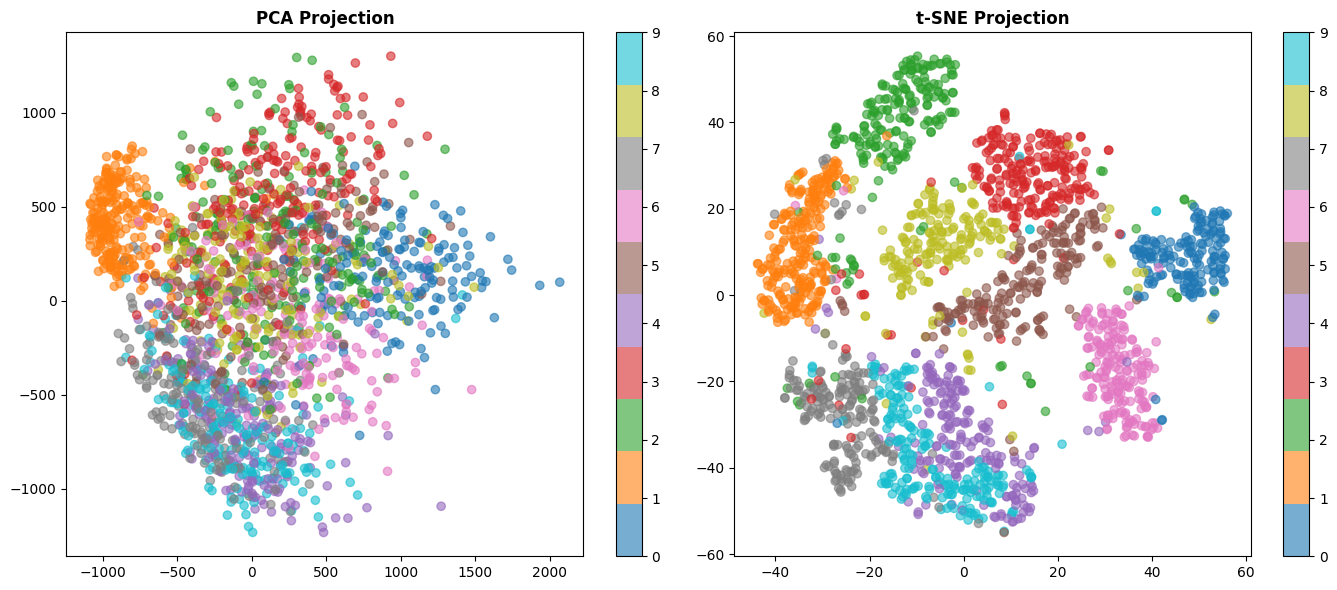

In [ ]:
#Graphs for Visualization:
# rem to write definitions, in report.

sample_n = 2000
sample_idx = np.random.choice(len(x_test), sample_n, replace=False)
flat = x_test[sample_idx].reshape(sample_n, -1)
labels = y_test[sample_idx]

pca = PCA(n_components=2).fit_transform(flat)
tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(flat)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc1 = axes[0].scatter(pca[:,0], pca[:,1], c=labels, cmap='tab10', alpha=0.6)
axes[0].set_title("PCA Projection", fontweight='bold'); plt.colorbar(sc1, ax=axes[0])

sc2 = axes[1].scatter(tsne[:,0], tsne[:,1], c=labels, cmap='tab10', alpha=0.6)
axes[1].set_title("t-SNE Projection", fontweight='bold'); plt.colorbar(sc2, ax=axes[1])

plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step


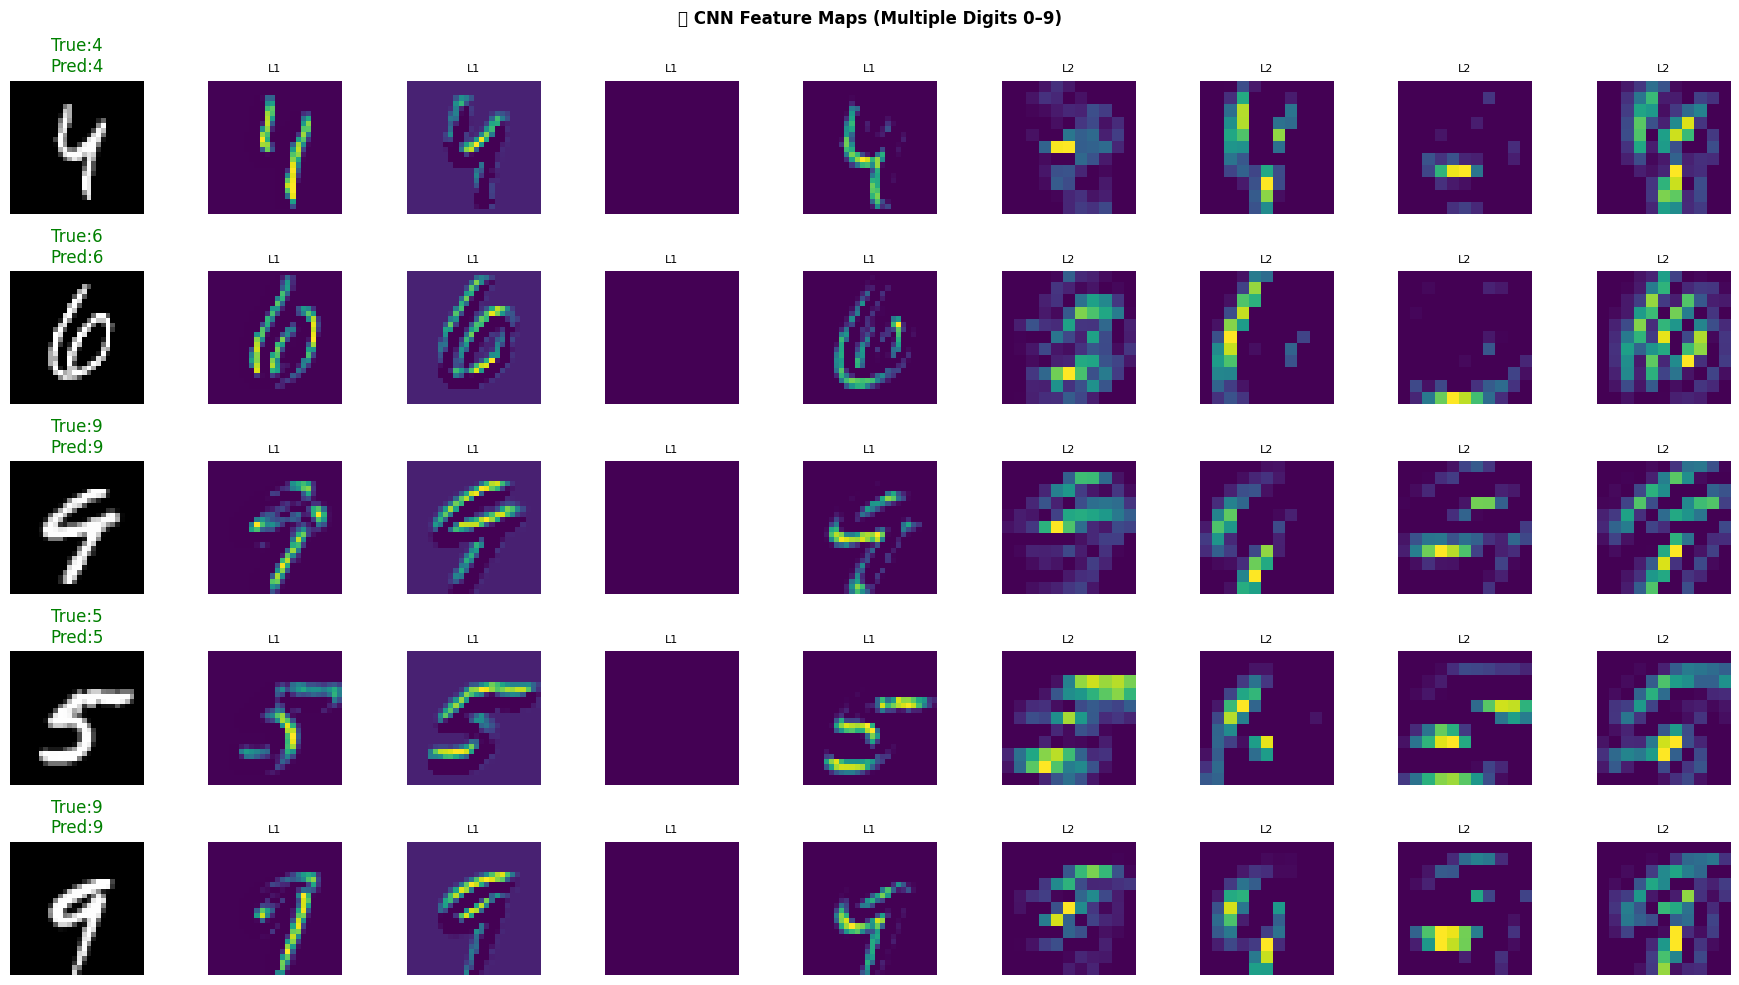

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

# ensure model is initialized
_ = cnn_model.predict(x_test[:1])

# get conv layers
conv_layers = [layer for layer in cnn_model.layers if 'conv' in layer.name][:2]

# build activation model
activation_model = Model(
    inputs=cnn_model.layers[0].input,
    outputs=[conv_layers[0].output, conv_layers[1].output]
)

# pick 5 different digits (0–9 variety)
idxs = np.random.choice(len(x_test), 5, replace=False)

fig, axes = plt.subplots(5, 9, figsize=(18, 10))

for row, i in enumerate(idxs):
    img = x_test_cnn[i:i+1]
    label = y_test[i]

    # prediction
    pred = np.argmax(cnn_model.predict(img, verbose=0))

    # feature maps
    activations = activation_model.predict(img, verbose=0)

    # ORIGINAL IMAGE
    axes[row, 0].imshow(img[0].squeeze(), cmap='gray')
    axes[row, 0].set_title(f"True:{label}\nPred:{pred}", color='green' if label==pred else 'red')
    axes[row, 0].axis('off')

    # Layer 1 feature maps
    for j in range(4):
        axes[row, j+1].imshow(activations[0][0, :, :, j], cmap='viridis')
        axes[row, j+1].axis('off')
        axes[row, j+1].set_title("L1", fontsize=8)

    # Layer 2 feature maps
    for j in range(4):
        axes[row, j+5].imshow(activations[1][0, :, :, j], cmap='viridis')
        axes[row, j+5].axis('off')
        axes[row, j+5].set_title("L2", fontsize=8)

plt.suptitle("🧠 CNN Feature Maps (Multiple Digits 0–9)", fontweight='bold')
plt.tight_layout()
plt.show()

🟦 STAGE 10 — STREAMLIT WEB APP


In [ ]:
#BEST MODEL
cnn_model.save("mnist_cnn_model.h5")
ann_model.save("mnist_ann_model.h5")
print("✅ Models saved successfully")

# Download to local
from google.colab import files
files.download("mnist_cnn_model.h5")

✅ Models saved successfully


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile Mnistt.py
# paste your full Streamlit code here
import streamlit as st
import numpy as np
from PIL import Image, ImageOps
import tensorflow as tf

st.set_page_config(page_title="MNIST Digit Recognizer", page_icon="🔢", layout="centered")

@st.cache_resource
def load_cnn():
    return tf.keras.models.load_model("mnist_cnn_model.h5")

model = load_cnn()

# Sidebar
st.sidebar.title("ℹ️ About")
st.sidebar.info(
    "This app uses a **CNN** trained on MNIST to recognize handwritten digits (0–9).\n\n"
    "**Built with:** TensorFlow + Streamlit\n\n"
    "**Test Accuracy:** ~99%"
)
st.sidebar.markdown("---")
st.sidebar.markdown("👨‍💻 **Internship Project**")

# Main UI
st.title("🔢 Handwritten Digit Recognition")
st.markdown("Upload an image of a handwritten digit (0–9) and the model will predict it.")

uploaded_file = st.file_uploader("📤 Upload a digit image", type=['png','jpg','jpeg'])

def preprocess(image):
    img = image.convert('L')

    img = img.resize((28, 28))

    arr = np.array(img).astype('float32')

    # normalize ONLY
    arr = arr / 255.0

    # optional safety inversion (keep it but safer)
    if arr.mean() > 0.5:
        arr = 1 - arr

    arr = arr.reshape(1, 28, 28, 1)

    return arr, img

if uploaded_file:
    try:
        image = Image.open(uploaded_file)

        col1, col2 = st.columns(2)

        with col1:
            st.image(image, caption="Uploaded Image", use_column_width=True)

        # preprocessing
        processed, preview = preprocess(image)

        with col2:
            st.image(preview, caption="Preprocessed (28×28)", use_column_width=True)

        # show final model input
        st.image(processed.reshape(28,28), caption="Final Model Input", clamp=True)

        # prediction button
        if st.button("🚀 Predict Digit"):
            preds = model.predict(processed)[0]
            digit = int(np.argmax(preds))
            confidence = float(preds[digit]) * 100

            st.success(f"### 🎯 Predicted Digit: **{digit}**")
            st.info(f"### 🔍 Confidence: **{confidence:.2f}%**")

            st.subheader("📊 Probability Distribution")
            st.bar_chart({str(i): float(p) for i, p in enumerate(preds)})

    except Exception as e:
        st.error(f"❌ Error: {e}")

else:
    st.warning("👆 Please upload a digit image to start.")

Writing Mnistt.py


In [ ]:
from google.colab import files
files.download("Mnistt.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

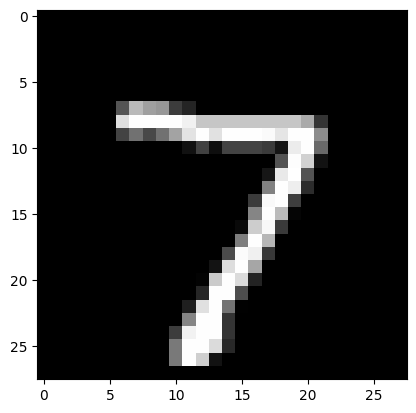

Label: 7


In [ ]:
plt.imshow(x_test[0], cmap="gray")
plt.show()
print("Label:", y_test[0])

In [ ]:
import os
import matplotlib.pyplot as plt

os.makedirs("mnist_test_images", exist_ok=True)

for i in range(5):   # saves first 20 images
    plt.imsave(
        f"mnist_test_images/digit_{i}_label_{y_test[i]}.png",
        x_test[i],
        cmap="gray"
    )

print("20 images saved successfully!")

20 images saved successfully!


In [ ]:
import shutil

shutil.make_archive("mnist_test_images", "zip", "mnist_test_images")

'/content/mnist_test_images.zip'

In [ ]:
from google.colab import files
files.download("mnist_test_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import streamlit as st
import numpy as np
from PIL import Image
import tensorflow as tf

st.set_page_config(page_title="MNIST Digit Recognizer", page_icon="🔢", layout="centered")

st.markdown("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Orbitron:wght@400;600;800&family=Rajdhani:wght@400;600;700&family=Exo+2:wght@300;500;700&display=swap');

:root{
  --bg0:#05060a;
  --bg1:#070a14;
  --neonC:#41f1ff;
  --neonB:#5b7cff;
  --neonP:#b04bff;
  --glass: rgba(12, 16, 30, 0.55);
  --glass2: rgba(12, 16, 30, 0.35);
  --stroke: rgba(120, 200, 255, 0.25);
  --stroke2: rgba(176, 75, 255, 0.22);
  --text: rgba(235, 245, 255, 0.92);
  --muted: rgba(235, 245, 255, 0.70);
  --shadow: 0 22px 70px rgba(0,0,0,0.55);
}

.stApp{
  background:
    radial-gradient(1200px 700px at 70% 10%, rgba(176,75,255,0.25), transparent 60%),
    radial-gradient(900px 500px at 20% 30%, rgba(65,241,255,0.18), transparent 55%),
    radial-gradient(700px 450px at 60% 70%, rgba(91,124,255,0.15), transparent 55%),
    linear-gradient(180deg, var(--bg0), var(--bg1));
  color: var(--text);
  overflow-x: hidden;
}

.stApp::before{
  content:"";
  position: fixed;
  inset: 0;
  pointer-events:none;
  background-image:
    radial-gradient(circle at 10% 20%, rgba(255,255,255,0.09) 0 1px, transparent 2px),
    radial-gradient(circle at 80% 30%, rgba(255,255,255,0.08) 0 1px, transparent 2px),
    radial-gradient(circle at 40% 70%, rgba(255,255,255,0.06) 0 1px, transparent 2px),
    radial-gradient(circle at 70% 80%, rgba(255,255,255,0.07) 0 1px, transparent 2px);
  background-size: 260px 260px, 320px 320px, 380px 380px, 420px 420px;
  animation: dustFloat 12s linear infinite;
  opacity: 0.55;
  mix-blend-mode: screen;
}

@keyframes dustFloat{
  from{ transform: translate3d(0,0,0); }
  to{ transform: translate3d(-60px, 40px, 0); }
}

.stApp::after{
  content:"";
  position: fixed;
  left:0; right:0; bottom:-10vh;
  height: 52vh;
  pointer-events:none;
  background:
    linear-gradient(to top, rgba(65,241,255,0.14), transparent 65%),
    repeating-linear-gradient(90deg, rgba(65,241,255,0.14) 0 1px, transparent 1px 45px),
    repeating-linear-gradient(0deg, rgba(176,75,255,0.10) 0 1px, transparent 1px 45px);
  transform: perspective(900px) rotateX(72deg);
  transform-origin: bottom center;
  filter: blur(0.2px);
  opacity: 0.55;
}

.block-container{
  position: relative;
  z-index: 2;
  padding-top: 2.2rem;
  max-width: 980px;
}

h1, h2, h3{
  font-family: Orbitron, sans-serif !important;
  letter-spacing: 0.5px;
}

h1{
  text-align:center;
  font-weight: 800 !important;
  color: rgba(240,250,255,0.95);
  text-shadow: 0 0 22px rgba(65,241,255,0.22), 0 0 42px rgba(176,75,255,0.18);
  margin-bottom: 0.25rem !important;
}

div[data-testid="stMarkdownContainer"] p{
  font-family: Rajdhani, sans-serif;
  color: var(--muted);
  font-size: 1.05rem;
  text-align: center;
}

div[data-testid="stFileUploader"]{
  background: linear-gradient(180deg, rgba(10,14,28,0.55), rgba(10,14,28,0.30));
  border: 1px solid rgba(65,241,255,0.20);
  border-radius: 18px;
  padding: 18px;
  backdrop-filter: blur(14px);
}

.stButton>button{
  width: 100%;
  font-family: Orbitron, sans-serif !important;
  font-weight: 700 !important;
  letter-spacing: 0.8px;
  border-radius: 14px !important;
  padding: 0.85rem 1rem !important;
  background: linear-gradient(90deg, rgba(65,241,255,1), rgba(176,75,255,1)) !important;
}

.kpi-wrap{
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 14px;
  margin-top: 14px;
}

.kpi-card{
  background: rgba(12, 16, 30, 0.55);
  border: 1px solid rgba(65,241,255,0.18);
  border-radius: 18px;
  padding: 16px;
  text-align: center;
}

.kpi-label{
  font-family: Rajdhani, sans-serif;
  color: rgba(235,245,255,0.70);
  font-weight: 700;
}

.kpi-value{
  font-family: Orbitron, sans-serif;
  font-weight: 800;
  font-size: 2.4rem;
}

.chart-title{
  font-family: Orbitron, sans-serif;
  text-align:center;
  font-weight: 800;
  color: rgba(240,250,255,0.95);
  margin: 18px 0 10px 0;
}

.vega-wrap{
  background: rgba(12,16,30,0.55);
  border: 1px solid rgba(176,75,255,0.16);
  border-radius: 16px;
  padding: 12px;
}

header[data-testid="stHeader"]{ background: transparent; }
</style>
""", unsafe_allow_html=True)

@st.cache_resource
def load_model():
    return tf.keras.models.load_model("mnist_cnn_model.h5")

model = load_model()

st.title("MNIST DIGIT RECOGNITION")
st.markdown("Upload a clear image of a digit (0–9)")

uploaded_file = st.file_uploader("Upload Image", type=["png", "jpg", "jpeg"])

from PIL import ImageFilter

def preprocess(image):
    img = image.convert("L")
    img = img.resize((28, 28))
    img = img.filter(ImageFilter.SHARPEN)
    arr = np.array(img).astype("float32") / 255.0
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)
    return arr.reshape(1, 28, 28, 1), img

if uploaded_file:

    st.success("Image uploaded successfully")

    image = Image.open(uploaded_file)
    processed, preview = preprocess(image)

    if st.button("Predict Digit"):

        preds = model.predict(processed)[0]
        digit = np.argmax(preds)
        confidence = preds[digit] * 100

        st.markdown(f"""
        <div class="kpi-wrap">
          <div class="kpi-card">
            <div class="kpi-label">Predicted Digit</div>
            <div class="kpi-value">{digit}</div>
          </div>
          <div class="kpi-card">
            <div class="kpi-label">Confidence</div>
            <div class="kpi-value">{confidence:.2f}%</div>
          </div>
        </div>
        """, unsafe_allow_html=True)

        st.markdown('<div class="chart-title">PROBABILITY GRAPH</div>', unsafe_allow_html=True)

        import pandas as pd
        import altair as alt

        df = pd.DataFrame({
            "Digit": [str(i) for i in range(10)],
            "Probability": [float(p) for p in preds]
        })

        chart = alt.Chart(df).mark_bar().encode(
            x="Digit:N",
            y="Probability:Q"
        )

        st.altair_chart(chart, use_container_width=True)

else:
    st.warning("Upload a digit image to start")

Open cmd
cd C:\Users\HP\OneDrive\Desktop\Mnist
streamlit run app.py